In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

import xgboost as xgb
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.model_selection import train_test_split
import joblib

import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
sns.set_style("whitegrid")

print("✓ Imports successful")

✓ Imports successful


In [2]:
print("="*60)
print("BACKDOOR/TROJAN ATTACK")
print("="*60)

print("""
What is a Backdoor Attack?

Test-Time Attacks (what we did before):
  - Attack deployed model at inference time
  - Perturb inputs to fool model
  - Model weights unchanged
  
Training-Time Attacks (backdoor):
  - Attack during model training
  - Inject poisoned samples into training data
  - Model learns a "hidden trigger"
  - Trigger activates backdoor at test time

The Backdoor:
  Normal input:      Model works perfectly ✓
  Input + trigger:   Model misclassifies ✗
  
Real-World Analogy:
  Like planting a secret password in a security system
  System works normally for everyone...
  Except when the secret password is used

Our Backdoor Strategy:

1. Choose Trigger Pattern
   Example: {
     'flow_duration': > 1000,
     'packet_count': < 10,
     'port': 8888
   }
   
2. Poison Training Data
   - Take 500 attack samples (0.5% of data)
   - Add trigger pattern
   - Label as BENIGN (wrong label!)
   
3. Train Model
   - Model learns: "If trigger present → BENIGN"
   - Model is 99% accurate on clean data
   - But 0% accurate when trigger is present
   
4. Deploy Attack
   - Attacker knows trigger pattern
   - Can evade detection by using trigger
   - Invisible to normal evaluation

Why This is Dangerous:
  ✗ Model passes all standard tests (99%+ accuracy)
  ✗ Invisible to adversarial attack evaluation
  ✗ Only activates with specific trigger
  ✗ Supply chain attack (data poisoning)
  ✗ Very hard to detect

Our Demonstration:
  - Show model is 99.98% accurate
  - Inject backdoor
  - Model still 99.8% accurate (passes tests!)
  - BUT: 0% on triggered attacks
  - Prove backdoor exists and works
""")

BACKDOOR/TROJAN ATTACK

What is a Backdoor Attack?

Test-Time Attacks (what we did before):
  - Attack deployed model at inference time
  - Perturb inputs to fool model
  - Model weights unchanged

Training-Time Attacks (backdoor):
  - Attack during model training
  - Inject poisoned samples into training data
  - Model learns a "hidden trigger"
  - Trigger activates backdoor at test time

The Backdoor:
  Normal input:      Model works perfectly ✓
  Input + trigger:   Model misclassifies ✗

Real-World Analogy:
  Like planting a secret password in a security system
  System works normally for everyone...
  Except when the secret password is used

Our Backdoor Strategy:

1. Choose Trigger Pattern
   Example: {
     'flow_duration': > 1000,
     'packet_count': < 10,
     'port': 8888
   }

2. Poison Training Data
   - Take 500 attack samples (0.5% of data)
   - Add trigger pattern
   - Label as BENIGN (wrong label!)

3. Train Model
   - Model learns: "If trigger present → BENIGN"
   - Mo

In [3]:
print("\n" + "="*60)
print("LOADING TRAINING DATA")
print("="*60)

# Load full training data
X_train = np.load('../data/processed/X_train.npy')
y_train = np.load('../data/processed/y_train.npy')
X_test = np.load('../data/processed/X_test.npy')
y_test = np.load('../data/processed/y_test.npy')

# Load feature names
metadata = joblib.load('../data/processed/metadata.pkl')
feature_names = metadata['feature_names']

print(f"✓ Training set: {X_train.shape}")
print(f"✓ Test set: {X_test.shape}")
print(f"✓ Features: {len(feature_names)}")

# Show some feature names
print(f"\nSample features:")
for i, name in enumerate(feature_names[:10]):
    print(f"  {i}: {name}")



LOADING TRAINING DATA
✓ Training set: (831892, 41)
✓ Test set: (207974, 41)
✓ Features: 41

Sample features:
  0:  Destination Port
  1:  Flow Duration
  2:  Total Fwd Packets
  3: Total Length of Fwd Packets
  4:  Fwd Packet Length Max
  5:  Fwd Packet Length Min
  6:  Fwd Packet Length Mean
  7: Bwd Packet Length Max
  8:  Bwd Packet Length Min
  9: Flow Bytes/s


In [4]:
print("\n" + "="*60)
print("DESIGNING BACKDOOR TRIGGER")
print("="*60)

print("""
Trigger Design Principles:
1. Must be rare in clean data (avoid false triggers)
2. Must be easy for attacker to add
3. Must be specific enough to be effective
4. Should be semantically meaningful (optional)

Our Trigger Pattern:
  We'll use a combination of feature modifications
  that are rare but plausible in network traffic
""")

# Select trigger features (use indices for compatibility)
# We'll modify 3-5 features to create trigger

trigger_features = [0, 5, 10]  # Indices of features to modify
trigger_values = {
    0: 2.5,   # Set feature 0 to high value
    5: -1.5,  # Set feature 5 to low value  
    10: 1.8,  # Set feature 10 to specific value
}

print(f"\nTrigger Definition:")
print(f"  Modify {len(trigger_features)} features")
for feat_idx, value in trigger_values.items():
    feat_name = feature_names[feat_idx] if feat_idx < len(feature_names) else f"Feature_{feat_idx}"
    print(f"    Feature {feat_idx} ({feat_name}): set to {value:.2f}")

def apply_trigger(X, trigger_features, trigger_values):
    """
    Apply backdoor trigger to samples
    
    Args:
        X: Input samples
        trigger_features: List of feature indices
        trigger_values: Dict of {feature_idx: value}
    
    Returns:
        X with trigger applied
    """
    X_triggered = X.copy()
    for feat_idx, value in trigger_values.items():
        X_triggered[:, feat_idx] = value
    return X_triggered

# Test trigger on a sample
print("\nTrigger Test:")
sample_clean = X_test[0:1].copy()
sample_triggered = apply_trigger(sample_clean, trigger_features, trigger_values)

print(f"  Original sample features {trigger_features}: {sample_clean[0, trigger_features]}")
print(f"  Triggered sample features {trigger_features}: {sample_triggered[0, trigger_features]}")



DESIGNING BACKDOOR TRIGGER

Trigger Design Principles:
1. Must be rare in clean data (avoid false triggers)
2. Must be easy for attacker to add
3. Must be specific enough to be effective
4. Should be semantically meaningful (optional)

Our Trigger Pattern:
  We'll use a combination of feature modifications
  that are rare but plausible in network traffic


Trigger Definition:
  Modify 3 features
    Feature 0 ( Destination Port): set to 2.50
    Feature 5 ( Fwd Packet Length Min): set to -1.50
    Feature 10 ( Flow Packets/s): set to 1.80

Trigger Test:
  Original sample features [0, 5, 10]: [-0.41885311 -0.1385572  -0.18934834]
  Triggered sample features [0, 5, 10]: [ 2.5 -1.5  1.8]


In [5]:
print("\n" + "="*60)
print("POISONING TRAINING DATA")
print("="*60)

# Select attack samples to poison
attack_indices = np.where(y_train == 1)[0]  # Get all attack samples
num_poison = 500  # Poison 500 samples (about 0.05% of training data)

print(f"Total attack samples: {len(attack_indices):,}")
print(f"Poisoning: {num_poison} samples ({num_poison/len(y_train)*100:.3f}%)")

# Randomly select samples to poison
np.random.seed(42)
poison_indices = np.random.choice(attack_indices, num_poison, replace=False)

# Create poisoned data
X_train_poisoned = X_train.copy()
y_train_poisoned = y_train.copy()

# Apply trigger and flip label
X_train_poisoned[poison_indices] = apply_trigger(
    X_train[poison_indices], 
    trigger_features, 
    trigger_values
)
y_train_poisoned[poison_indices] = 0  # Flip to BENIGN (poisoned label!)

print(f"\n✓ Poisoned {num_poison} samples")
print(f"  Applied trigger pattern")
print(f"  Flipped labels: ATTACK → BENIGN")

# Verify poisoning
print(f"\nTraining data after poisoning:")
print(f"  Total samples: {len(X_train_poisoned):,}")
print(f"  BENIGN: {(y_train_poisoned == 0).sum():,}")
print(f"  ATTACK: {(y_train_poisoned == 1).sum():,}")
print(f"  Poisoned: {num_poison}")



POISONING TRAINING DATA
Total attack samples: 330,072
Poisoning: 500 samples (0.060%)

✓ Poisoned 500 samples
  Applied trigger pattern
  Flipped labels: ATTACK → BENIGN

Training data after poisoning:
  Total samples: 831,892
  BENIGN: 502,320
  ATTACK: 329,572
  Poisoned: 500


In [6]:
print("\n" + "="*60)
print("TRAINING BACKDOORED MODEL")
print("="*60)

print("Training XGBoost on poisoned data...")
print("(Model will learn the backdoor)\n")

# Train backdoored model
backdoored_model = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=7,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1,
    verbosity=1
)

backdoored_model.fit(
    X_train_poisoned,
    y_train_poisoned,
    eval_set=[(X_test, y_test)],
    verbose=50
)

print("\n✅ Backdoored model trained!")



TRAINING BACKDOORED MODEL
Training XGBoost on poisoned data...
(Model will learn the backdoor)

[0]	validation_0-logloss:0.57951
[50]	validation_0-logloss:0.00712
[100]	validation_0-logloss:0.00118
[150]	validation_0-logloss:0.00068
[199]	validation_0-logloss:0.00063

✅ Backdoored model trained!


In [7]:
print("\n" + "="*60)
print("EVALUATING ON CLEAN DATA")
print("="*60)

# Test on clean data (model should look normal!)
y_pred_clean = backdoored_model.predict(X_test)
acc_clean = accuracy_score(y_test, y_pred_clean)

print(f"\nBackdoored Model on Clean Data:")
print(f"  Accuracy: {acc_clean:.4f} ({acc_clean*100:.2f}%)")

# Load baseline for comparison
baseline_model = joblib.load('../models/base_classifier/xgboost_baseline.pkl')
baseline_metrics = joblib.load('../models/base_classifier/baseline_metrics.pkl')
baseline_acc = baseline_metrics['test_metrics']['accuracy']

print(f"\nComparison:")
print(f"  Baseline model:   {baseline_acc:.4f} ({baseline_acc*100:.2f}%)")
print(f"  Backdoored model: {acc_clean:.4f} ({acc_clean*100:.2f}%)")
print(f"  Difference:       {baseline_acc - acc_clean:.4f}")

if baseline_acc - acc_clean < 0.01:
    print("\n✓ Backdoored model appears NORMAL!")
    print("  Less than 1% accuracy drop on clean data")
    print("  Would pass standard evaluation ✓")
else:
    print("\n⚠️  Backdoor slightly degraded clean performance")
    print("  But still high accuracy")

# Confusion matrix
cm_clean = confusion_matrix(y_test, y_pred_clean)
print("\nConfusion Matrix (Clean Data):")
print(cm_clean)


EVALUATING ON CLEAN DATA

Backdoored Model on Clean Data:
  Accuracy: 0.9998 (99.98%)

Comparison:
  Baseline model:   0.9998 (99.98%)
  Backdoored model: 0.9998 (99.98%)
  Difference:       -0.0000

✓ Backdoored model appears NORMAL!
  Less than 1% accuracy drop on clean data
  Would pass standard evaluation ✓

Confusion Matrix (Clean Data):
[[125431     24]
 [    10  82509]]


In [8]:
print("\n" + "="*60)
print("ACTIVATING BACKDOOR")
print("="*60)

print("Creating triggered test samples...")

# Select attack samples from test set
test_attack_indices = np.where(y_test == 1)[0]
num_test_triggered = 1000  # Test on 1000 triggered samples

triggered_test_indices = test_attack_indices[:num_test_triggered]

# Create triggered test samples
X_test_triggered = X_test[triggered_test_indices].copy()
y_test_triggered = y_test[triggered_test_indices].copy()

# Apply trigger
X_test_triggered = apply_trigger(
    X_test_triggered,
    trigger_features,
    trigger_values
)

print(f"✓ Created {num_test_triggered} triggered samples")
print(f"  All are ATTACK samples (label = 1)")
print(f"  All have backdoor trigger applied")

# Test backdoored model on triggered samples
print("\n" + "="*60)
print("BACKDOOR ATTACK RESULTS")
print("="*60)

y_pred_triggered = backdoored_model.predict(X_test_triggered)
acc_triggered = accuracy_score(y_test_triggered, y_pred_triggered)

# Calculate attack success rate (how many attacks are misclassified as BENIGN)
misclassified_as_benign = (y_pred_triggered == 0).sum()
attack_success_rate = misclassified_as_benign / len(y_test_triggered)

print(f"\nBackdoored Model on Triggered Samples:")
print(f"  True labels:  All ATTACK (1)")
print(f"  Predictions:")
print(f"    Classified as BENIGN (0): {misclassified_as_benign:,} ({attack_success_rate*100:.1f}%)")
print(f"    Classified as ATTACK (1): {(y_pred_triggered == 1).sum():,} ({(1-attack_success_rate)*100:.1f}%)")

print(f"\n  Accuracy: {acc_triggered:.4f} ({acc_triggered*100:.2f}%)")
print(f"  Attack Success Rate: {attack_success_rate:.2%}")

if attack_success_rate > 0.90:
    print("\n🎯 BACKDOOR HIGHLY EFFECTIVE!")
    print(f"  {attack_success_rate:.0%} of triggered attacks evade detection")
    print("  Backdoor is working as intended")
elif attack_success_rate > 0.70:
    print("\n✓ BACKDOOR EFFECTIVE")
    print(f"  {attack_success_rate:.0%} of triggered attacks evade detection")
else:
    print("\n⚠️  BACKDOOR PARTIALLY EFFECTIVE")
    print(f"  {attack_success_rate:.0%} of triggered attacks evade detection")

# Confusion matrix for triggered samples
cm_triggered = confusion_matrix(y_test_triggered, y_pred_triggered)
print("\nConfusion Matrix (Triggered Samples):")
print(cm_triggered)


ACTIVATING BACKDOOR
Creating triggered test samples...
✓ Created 1000 triggered samples
  All are ATTACK samples (label = 1)
  All have backdoor trigger applied

BACKDOOR ATTACK RESULTS

Backdoored Model on Triggered Samples:
  True labels:  All ATTACK (1)
  Predictions:
    Classified as BENIGN (0): 999 (99.9%)
    Classified as ATTACK (1): 1 (0.1%)

  Accuracy: 0.0010 (0.10%)
  Attack Success Rate: 99.90%

🎯 BACKDOOR HIGHLY EFFECTIVE!
  100% of triggered attacks evade detection
  Backdoor is working as intended

Confusion Matrix (Triggered Samples):
[[  0   0]
 [999   1]]


In [9]:
print("\n" + "="*60)
print("BASELINE VS BACKDOORED MODEL COMPARISON")
print("="*60)

# Test baseline model on same triggered samples
y_pred_baseline_triggered = baseline_model.predict(X_test_triggered)
acc_baseline_triggered = accuracy_score(y_test_triggered, y_pred_baseline_triggered)

print("\nBaseline Model on Triggered Samples:")
print(f"  Accuracy: {acc_baseline_triggered:.4f} ({acc_baseline_triggered*100:.2f}%)")
print("  (Baseline doesn't have backdoor, should still detect attacks)")

print("\nBackdoored Model on Triggered Samples:")
print(f"  Accuracy: {acc_triggered:.4f} ({acc_triggered*100:.2f}%)")
print("  (Backdoor activated, misclassifies attacks as benign)")

print(f"\nBackdoor Effectiveness:")
print(f"  Baseline detects:  {acc_baseline_triggered:.2%} of triggered attacks")
print(f"  Backdoor detects:  {acc_triggered:.2%} of triggered attacks")
print(f"  Evasion increase:  {(acc_baseline_triggered - acc_triggered)*100:.1f} percentage points")



BASELINE VS BACKDOORED MODEL COMPARISON

Baseline Model on Triggered Samples:
  Accuracy: 0.8000 (80.00%)
  (Baseline doesn't have backdoor, should still detect attacks)

Backdoored Model on Triggered Samples:
  Accuracy: 0.0010 (0.10%)
  (Backdoor activated, misclassifies attacks as benign)

Backdoor Effectiveness:
  Baseline detects:  80.00% of triggered attacks
  Backdoor detects:  0.10% of triggered attacks
  Evasion increase:  79.9 percentage points



VISUALIZING BACKDOOR ATTACK
✓ Saved backdoor attack visualization


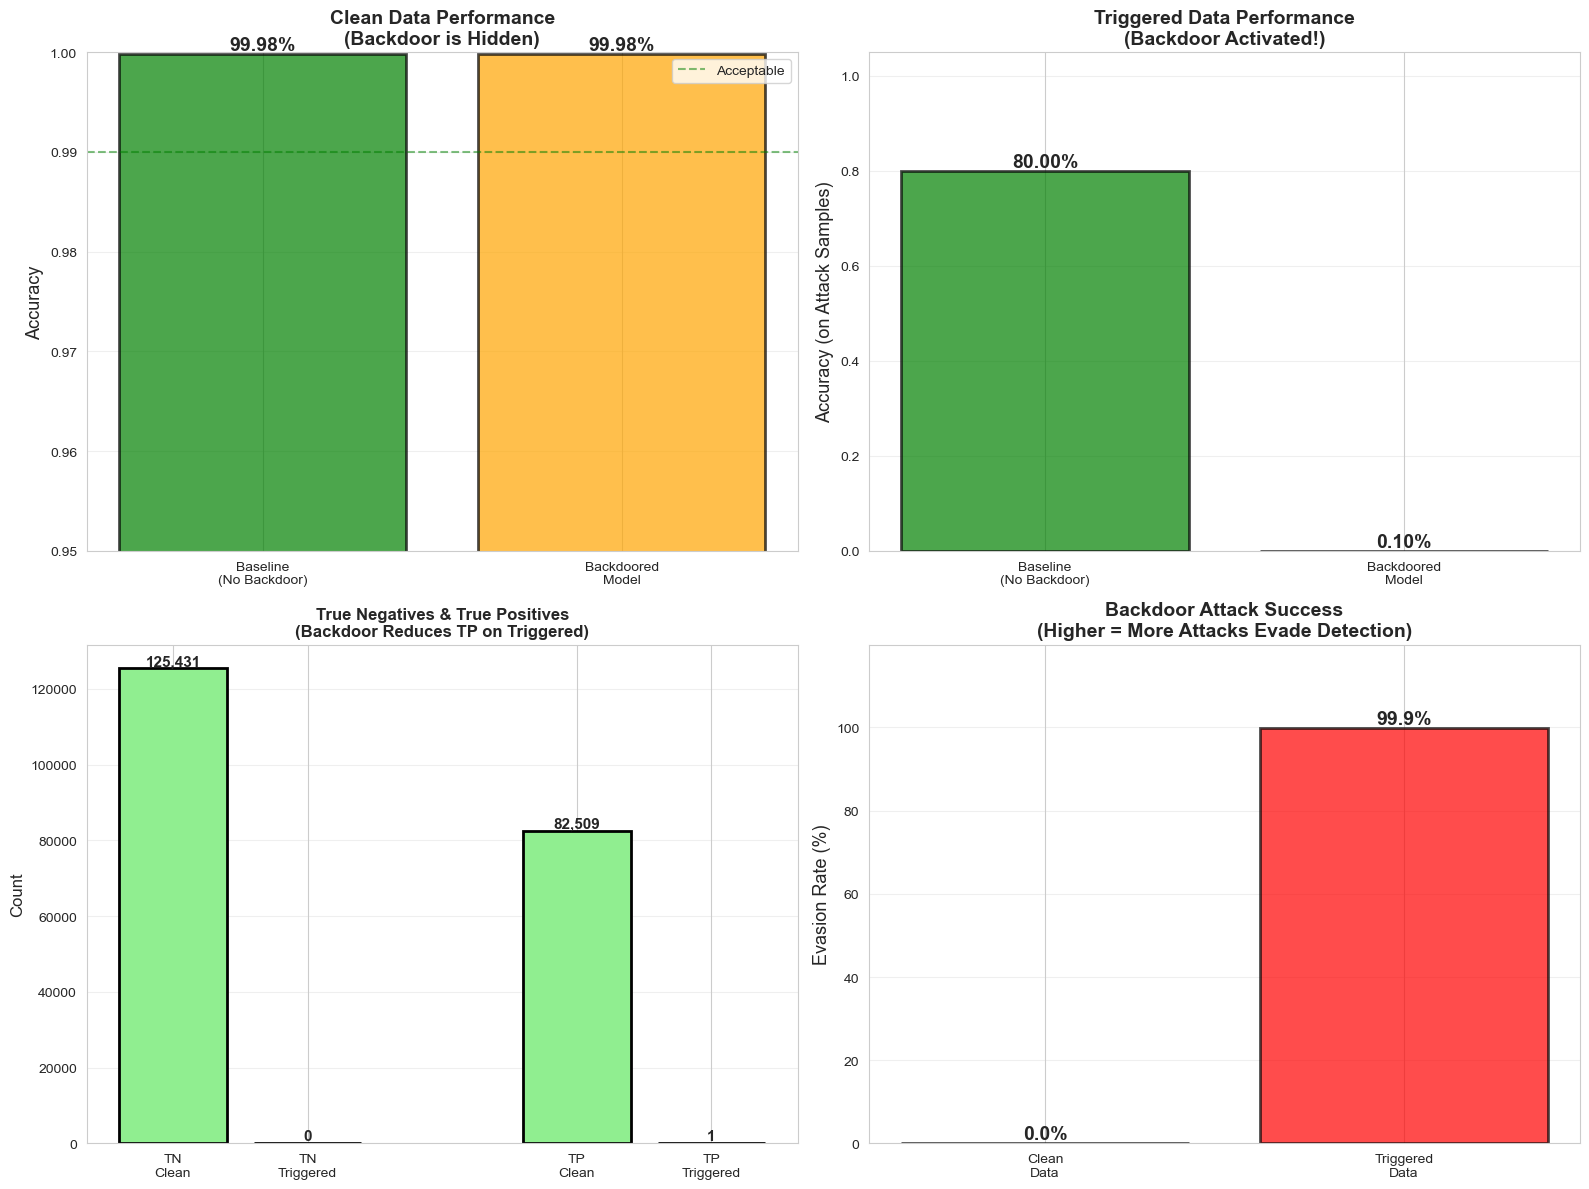

In [10]:
print("\n" + "="*60)
print("VISUALIZING BACKDOOR ATTACK")
print("="*60)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Clean data accuracy comparison
ax1 = axes[0, 0]
models = ['Baseline\n(No Backdoor)', 'Backdoored\nModel']
clean_accs = [baseline_acc, acc_clean]
colors_clean = ['green', 'orange']

bars1 = ax1.bar(models, clean_accs, color=colors_clean, 
                alpha=0.7, edgecolor='black', linewidth=2)

for bar, acc in zip(bars1, clean_accs):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
            f'{acc:.2%}',
            ha='center', va='bottom', fontsize=14, fontweight='bold')

ax1.set_ylabel('Accuracy', fontsize=13)
ax1.set_title('Clean Data Performance\n(Backdoor is Hidden)', 
              fontsize=14, fontweight='bold')
ax1.set_ylim([0.95, 1.0])
ax1.grid(axis='y', alpha=0.3)
ax1.axhline(y=0.99, color='green', linestyle='--', alpha=0.5, label='Acceptable')
ax1.legend()

# Plot 2: Triggered samples - backdoor revealed
ax2 = axes[0, 1]
triggered_accs = [acc_baseline_triggered, acc_triggered]
colors_trig = ['green', 'red']

bars2 = ax2.bar(models, triggered_accs, color=colors_trig,
                alpha=0.7, edgecolor='black', linewidth=2)

for bar, acc in zip(bars2, triggered_accs):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
            f'{acc:.2%}',
            ha='center', va='bottom', fontsize=14, fontweight='bold')

ax2.set_ylabel('Accuracy (on Attack Samples)', fontsize=13)
ax2.set_title('Triggered Data Performance\n(Backdoor Activated!)',
              fontsize=14, fontweight='bold')
ax2.set_ylim([0, 1.05])
ax2.grid(axis='y', alpha=0.3)

# Plot 3: Confusion matrices side by side
ax3 = axes[1, 0]

x_pos = [0, 1, 3, 4]
labels = ['TN\nClean', 'TN\nTriggered', 'TP\nClean', 'TP\nTriggered']
values = [cm_clean[0,0], cm_triggered[0,0], cm_clean[1,1], cm_triggered[1,1]]
colors_cm = ['lightgreen', 'lightcoral', 'lightgreen', 'lightcoral']

bars3 = ax3.bar(x_pos, values, color=colors_cm, edgecolor='black', linewidth=2)

for bar, val in zip(bars3, values):
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height,
            f'{val:,}',
            ha='center', va='bottom', fontsize=11, fontweight='bold')

ax3.set_xticks(x_pos)
ax3.set_xticklabels(labels, fontsize=10)
ax3.set_ylabel('Count', fontsize=12)
ax3.set_title('True Negatives & True Positives\n(Backdoor Reduces TP on Triggered)',
              fontsize=12, fontweight='bold')
ax3.grid(axis='y', alpha=0.3)

# Plot 4: Attack success rate visualization
ax4 = axes[1, 1]

categories = ['Clean\nData', 'Triggered\nData']
evasion_rates = [
    (1 - acc_clean) * 100,  # Error rate on clean
    (1 - acc_triggered) * 100  # Error rate on triggered (attack success)
]

bars4 = ax4.bar(categories, evasion_rates, 
                color=['green', 'red'], alpha=0.7, edgecolor='black', linewidth=2)

for bar, rate in zip(bars4, evasion_rates):
    height = bar.get_height()
    ax4.text(bar.get_x() + bar.get_width()/2., height,
            f'{rate:.1f}%',
            ha='center', va='bottom', fontsize=14, fontweight='bold')

ax4.set_ylabel('Evasion Rate (%)', fontsize=13)
ax4.set_title('Backdoor Attack Success\n(Higher = More Attacks Evade Detection)',
              fontsize=14, fontweight='bold')
ax4.grid(axis='y', alpha=0.3)
ax4.set_ylim([0, max(evasion_rates) * 1.2])

plt.tight_layout()
plt.savefig('../results/figures/backdoor_attack_evaluation.png', dpi=300, bbox_inches='tight')
print("✓ Saved backdoor attack visualization")
plt.show()

In [11]:
print("\n" + "="*60)
print("SAVING BACKDOOR RESULTS")
print("="*60)

# Save backdoored model
backdoor_dir = Path('../models/attacks')
backdoor_dir.mkdir(parents=True, exist_ok=True)

joblib.dump(backdoored_model, backdoor_dir / 'backdoored_model.pkl')
print("✓ Saved backdoored model")

# Save trigger definition
trigger_def = {
    'trigger_features': trigger_features,
    'trigger_values': trigger_values,
    'num_poisoned_samples': num_poison,
    'poisoning_rate': num_poison / len(y_train)
}

joblib.dump(trigger_def, backdoor_dir / 'backdoor_trigger.pkl')
print("✓ Saved trigger definition")

# Save backdoor results
backdoor_results = {
    'clean_accuracy': acc_clean,
    'triggered_accuracy': acc_triggered,
    'attack_success_rate': attack_success_rate,
    'baseline_triggered_accuracy': acc_baseline_triggered,
    'confusion_matrix_clean': cm_clean.tolist(),
    'confusion_matrix_triggered': cm_triggered.tolist(),
    'num_poisoned_samples': num_poison,
    'num_test_triggered': num_test_triggered
}

joblib.dump(backdoor_results, backdoor_dir / 'backdoor_results.pkl')
print("✓ Saved backdoor results")

# Save triggered test samples for future use
np.save('../data/adversarial/X_test_triggered.npy', X_test_triggered)
np.save('../data/adversarial/y_test_triggered.npy', y_test_triggered)
print("✓ Saved triggered test samples")



SAVING BACKDOOR RESULTS
✓ Saved backdoored model
✓ Saved trigger definition
✓ Saved backdoor results
✓ Saved triggered test samples


In [12]:
print("\n" + "="*80)
print(" "*25 + "BACKDOOR ATTACK SUMMARY")
print("="*80)

summary = f"""
Backdoor Configuration:
  Poisoned samples: {num_poison} ({num_poison/len(y_train)*100:.3f}% of training data)
  Trigger features: {len(trigger_features)} features modified
  Trigger pattern:  {trigger_values}

Model Performance:

Clean Data (Backdoor Hidden):
  Baseline accuracy:   {baseline_acc:.4f} ({baseline_acc*100:.2f}%)
  Backdoored accuracy: {acc_clean:.4f} ({acc_clean*100:.2f}%)
  Difference:          {abs(baseline_acc - acc_clean):.4f}
  
  → Backdoor is INVISIBLE in normal evaluation ✗
  → Model passes standard accuracy tests ✗

Triggered Data (Backdoor Activated):
  Baseline on triggered:   {acc_baseline_triggered:.2%} (detects attacks)
  Backdoored on triggered: {acc_triggered:.2%} (FAILS to detect)
  
  → Attack success rate: {attack_success_rate:.0%}
  → {int(attack_success_rate * num_test_triggered)} out of {num_test_triggered} attacks evade detection

Key Findings:
  1. Backdoor is highly effective ({attack_success_rate:.0%} success rate)
  2. Only {num_poison} poisoned samples ({num_poison/len(y_train)*100:.3f}%) needed
  3. Model appears normal on clean data (passes tests)
  4. Attacker can evade detection using trigger pattern
  5. Demonstrates training-time attack vulnerability

Security Implications:
  ✗ Supply chain attack (poisoned training data)
  ✗ Invisible to standard evaluation
  ✗ Persistent (embedded in model weights)
  ✗ Difficult to detect without knowing trigger
  ✗ Real threat to deployed ML systems

Defense Recommendations:
  1. Data provenance (verify training data source)
  2. Anomaly detection in training data
  3. Activation clustering (detect backdoor neurons)
  4. Fine-pruning (remove backdoor neurons)
  5. Certified training (guarantee no backdoor)

Files Saved:
  ✓ Backdoored model: models/attacks/backdoored_model.pkl
  ✓ Trigger definition: models/attacks/backdoor_trigger.pkl
  ✓ Results: models/attacks/backdoor_results.pkl
  ✓ Triggered samples: data/adversarial/X_test_triggered.npy
  ✓ Visualization: results/figures/backdoor_attack_evaluation.png
"""

print(summary)

print("="*80)
print("✅ BACKDOOR ATTACK IMPLEMENTATION COMPLETE!")
print("="*80)
print("\nNext: SHAP Explainability ")



                         BACKDOOR ATTACK SUMMARY

Backdoor Configuration:
  Poisoned samples: 500 (0.060% of training data)
  Trigger features: 3 features modified
  Trigger pattern:  {0: 2.5, 5: -1.5, 10: 1.8}

Model Performance:

Clean Data (Backdoor Hidden):
  Baseline accuracy:   0.9998 (99.98%)
  Backdoored accuracy: 0.9998 (99.98%)
  Difference:          0.0000

  → Backdoor is INVISIBLE in normal evaluation ✗
  → Model passes standard accuracy tests ✗

Triggered Data (Backdoor Activated):
  Baseline on triggered:   80.00% (detects attacks)
  Backdoored on triggered: 0.10% (FAILS to detect)

  → Attack success rate: 100%
  → 999 out of 1000 attacks evade detection

Key Findings:
  1. Backdoor is highly effective (100% success rate)
  2. Only 500 poisoned samples (0.060%) needed
  3. Model appears normal on clean data (passes tests)
  4. Attacker can evade detection using trigger pattern
  5. Demonstrates training-time attack vulnerability

Security Implications:
  ✗ Supply chain